# DLAV Project - Phase 1

In this notebook we will train a very simple planner on data coming from a driving simulator. You are given a dash cam image of the current state of the driving vehicle, and the past positions of this vehicle, and you are asked to plan its future route.

This notebook will take you through steps on building this planner to solve the task. The full skeleton of the code together with some very simple implementations of each module are provided for your comfort. So all the cells below will run without you needing to change anything, but the performance won't be very good. You are asked to re-implement and play with most of the modules yourself to be able to have better performance.

P.S. to enable fast compute, you should use GPUs in google colab. The code works without GPUs, but it'll be much faster to use GPUs, specially if your model gets bigger and bigger! You can utilize Colab's GPUs by selecting "Change runtime type" in the Runtime menu on top of this page. There you can select "T4 GPU". This would restart your runtime, so you'll need to re-run everything from the top.

The first step is to prepare the data. The code below will download the data from google drive and extract it here for your code to use. Whenever your session gets restarted, remember to re-run this cell to re-download the data.

In [27]:
# Install gdown to handle Google Drive file download
!pip install -q gdown

import gdown
import zipfile

download_url = f"https://drive.google.com/uc?id=1YkGwaxBKNiYL2nq--cB6WMmYGzRmRKVr"
output_zip = "dlav_train.zip"
gdown.download(download_url, output_zip, quiet=False)  # Downloads the file to your drive
with zipfile.ZipFile(output_zip, 'r') as zip_ref:  # Extracts the downloaded zip file
    zip_ref.extractall(".")

download_url = "https://drive.google.com/uc?id=1wtmT_vH9mMUNOwrNOMFP6WFw6e8rbOdu"
output_zip = "dlav_val.zip"
gdown.download(download_url, output_zip, quiet=False)
with zipfile.ZipFile(output_zip, 'r') as zip_ref:
    zip_ref.extractall(".")

download_url = "https://drive.google.com/uc?id=1G9xGE7s-Ikvvc2-LZTUyuzhWAlNdLTLV"
output_zip = "dlav_test_public.zip"
gdown.download(download_url, output_zip, quiet=False)
with zipfile.ZipFile(output_zip, 'r') as zip_ref:
    zip_ref.extractall(".")

Downloading...
From (original): https://drive.google.com/uc?id=1YkGwaxBKNiYL2nq--cB6WMmYGzRmRKVr
From (redirected): https://drive.google.com/uc?id=1YkGwaxBKNiYL2nq--cB6WMmYGzRmRKVr&confirm=t&uuid=04ee248a-3c41-47cb-93ef-3ef12bfc9977
To: /content/dlav_train.zip
100%|██████████| 439M/439M [00:03<00:00, 120MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1wtmT_vH9mMUNOwrNOMFP6WFw6e8rbOdu
From (redirected): https://drive.google.com/uc?id=1wtmT_vH9mMUNOwrNOMFP6WFw6e8rbOdu&confirm=t&uuid=21272d30-8212-4693-8c7e-2e48d5ce78bb
To: /content/dlav_val.zip
100%|██████████| 87.8M/87.8M [00:02<00:00, 39.8MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1G9xGE7s-Ikvvc2-LZTUyuzhWAlNdLTLV
From (redirected): https://drive.google.com/uc?id=1G9xGE7s-Ikvvc2-LZTUyuzhWAlNdLTLV&confirm=t&uuid=3e5094e2-432c-46d7-b06c-ce6765c69bdc
To: /content/dlav_test_public.zip
100%|██████████| 86.6M/86.6M [00:00<00:00, 106MB/s]


Now lets load the data and visualize the first few examples to see what we are dealing with!

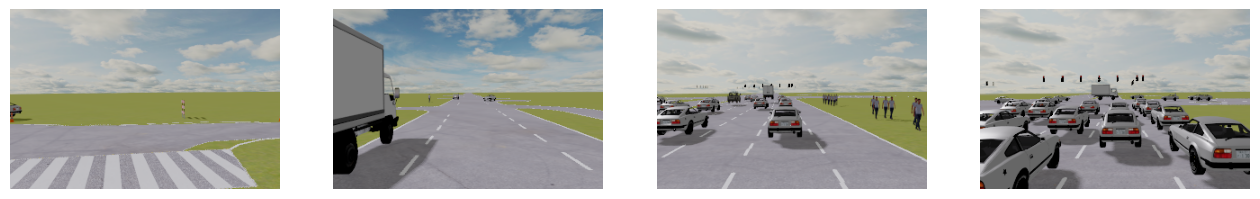

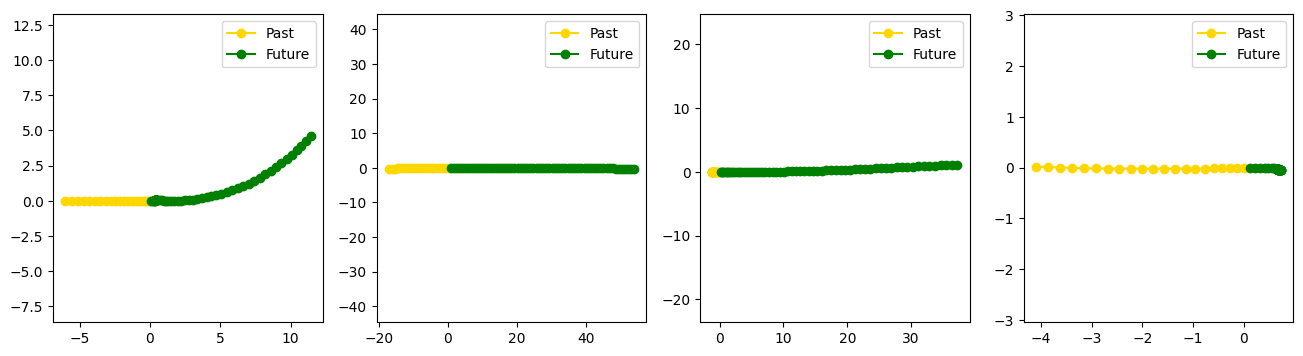

In [28]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import random

k = 4
# load the data
data = []
for i in random.choices(np.arange(1000), k=k):
    with open(f"train/{i}.pkl", "rb") as f:
        data.append(pickle.load(f))

# plot the camera view of current step for the k examples
fig, axis = plt.subplots(1, k, figsize=(4*k, 4))
for i in range(k):
    axis[i].imshow(data[i]["camera"])
    axis[i].axis("off")
plt.show()

# plot the past and future trajectory of the vehicle
fig, axis = plt.subplots(1, k, figsize=(4*k, 4))
for i in range(k):
    axis[i].plot(data[i]["sdc_history_feature"][:, 0], data[i]["sdc_history_feature"][:, 1], "o-", color="gold", label="Past")
    axis[i].plot(data[i]["sdc_future_feature"][:, 0], data[i]["sdc_future_feature"][:, 1], "o-", color="green", label="Future")
    axis[i].legend()
    axis[i].axis("equal")
plt.show()

Now its time to make our hands dirty!

In the following cells we will define the classes we need to do a proper training in pytorch.

1. We will start with defining a Dataset class which loads the data and does some basic preprocessing. You can further process this data as you see fit.
2. We then define the logger which receives training metrics and logs and prints/visualizes them. Having a good logger means a lot when dealing with neural network training! The logger implemented here is very simple and we strongly suggest you try other ways of visualizing your losses and metrics. Be creative ;)
3. We then proceed with defining the core part of the pipeline, the model. You are going to mainly implement the model yourself, but we have provided a very simple model so that the code runs as is so that you can see how the whole framework runs all in all.
4. Finally, we define the training funciton which contains the training loop, and we call it to see the magic! You'll need to also do a lot of changes here, from the batch size and learning rate, to adding augmentation schemes and schedulers, etc.

In [29]:
import torch
from torch.utils.data import Dataset
import pickle
import numpy as np

class DrivingDataset(Dataset):
    def __init__(self, file_list, test=False, num_waypoints=6):
        self.samples = file_list
        self.test = test
        self.num_waypoints = num_waypoints

    def __len__(self):
        return len(self.samples)

    @staticmethod
    def _extract_command(data):
        candidate_keys = [
            'command',
            'nav_command',
            'navigation_command',
            'high_level_command',
            'goal_command'
        ]
        command = 1
        for k in candidate_keys:
            if k in data:
                command = data[k]
                break

        if isinstance(command, str):
            mapping = {'left': 0, 'forward': 1, 'straight': 1, 'right': 2}
            command = mapping.get(command.lower(), 1)
        return torch.tensor(int(command), dtype=torch.long)

    @staticmethod
    def _extract_intrinsics(data, h, w):
        candidate_keys = ['K', 'intrinsics', 'camera_intrinsic', 'camera_intrinsics']
        K = None
        for k in candidate_keys:
            if k in data:
                K = np.asarray(data[k], dtype=np.float32)
                break

        if K is None or K.shape != (3, 3):
            fx = float(max(h, w))
            fy = float(max(h, w))
            cx = float(w) / 2.0
            cy = float(h) / 2.0
            K = np.array([[fx, 0.0, cx], [0.0, fy, cy], [0.0, 0.0, 1.0]], dtype=np.float32)
        return torch.from_numpy(K)

    def __getitem__(self, idx):
        with open(self.samples[idx], 'rb') as f:
            data = pickle.load(f)

        camera = torch.from_numpy(data['camera']).float().permute(2, 0, 1) / 255.0
        history = torch.from_numpy(data['sdc_history_feature']).float()
        _, h, w = camera.shape

        sample = {
            'camera': camera,
            'history': history,
            'command': self._extract_command(data),
            'K': self._extract_intrinsics(data, h, w),
        }

        if not self.test:
            future = torch.from_numpy(data['sdc_future_feature']).float()[..., :2]
            waypoint_idx = torch.linspace(0, future.shape[0] - 1, self.num_waypoints).long()
            sample['future'] = future[waypoint_idx]

        return sample

In [30]:
class Logger:
    def __init__(self):
        # Placeholder for potential future configs (e.g., log_dir, wandb_enabled, etc.)
        pass

    def log(self, step=None, **metrics):
        """
        Logs the given metrics.

        Args:
            step (int, optional): The current step or epoch. Useful for tracking.
            **metrics: Arbitrary keyword arguments representing metric names and values.
        """
        prefix = f"[Step {step}] " if step is not None else ""
        metric_str = " | ".join(f"{k}: {v}" for k, v in metrics.items())
        # print(prefix + metric_str)

In [38]:
import subprocess
import sys

import torch
import torch.nn as nn
import torch.nn.functional as F

try:
    import timm
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "timm"])
    import timm


class SwinFeatureExtractor(nn.Module):
    def __init__(self, pretrained=True, freeze_early_stages=True):
        super().__init__()
        self.backbone = timm.create_model(
            "swin_tiny_patch4_window7_224",
            pretrained=pretrained,
            features_only=True,
            out_indices=(1, 2, 3),
            # removed img_size — let timm use default 224
        )

        if freeze_early_stages:
            for name, param in self.backbone.named_parameters():
                if "layers.0" in name or "layers.1" in name:
                    param.requires_grad = False

    def forward(self, x):
        # resize 200→224 before backbone
        x = F.interpolate(x, size=(224, 224), mode='bilinear', align_corners=False)
        p2, p3, p4 = self.backbone(x)
        return p2, p3, p4

In [45]:
class LSSProjector(nn.Module):
    def __init__(
        self,
        bev_dim=128,
        bev_h=200,
        bev_w=200,
        depth_bins=32,
        depth_min=1.0,
        depth_max=60.0,
        x_range=(-50.0, 50.0),
        y_range=(-50.0, 50.0),
    ):
        super().__init__()
        self.bev_dim = bev_dim
        self.bev_h = bev_h
        self.bev_w = bev_w
        self.depth_bins = depth_bins
        self.x_range = x_range
        self.y_range = y_range

        self.p2_proj = nn.LazyConv2d(bev_dim, kernel_size=1)
        self.p3_proj = nn.LazyConv2d(bev_dim, kernel_size=1)
        self.p4_proj = nn.LazyConv2d(bev_dim, kernel_size=1)

        self.depth_head = nn.Sequential(
            nn.Conv2d(bev_dim, bev_dim, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(bev_dim, depth_bins, kernel_size=1),
        )

        self.bev_refine = nn.Sequential(
            nn.Conv2d(bev_dim, bev_dim, kernel_size=3, padding=1),
            nn.BatchNorm2d(bev_dim),
            nn.ReLU(inplace=True),
            nn.Conv2d(bev_dim, bev_dim, kernel_size=3, padding=1),
            nn.BatchNorm2d(bev_dim),
            nn.ReLU(inplace=True),
        )

        self.register_buffer(
            "depth_values",
            torch.linspace(depth_min, depth_max, depth_bins).float(),
            persistent=False,
        )

    def _lift_splat(self, feat_img, depth_prob, K):
      b, c, h, w = feat_img.shape
      d = depth_prob.shape[1]
      device = feat_img.device

      u = torch.arange(w, device=device, dtype=torch.float32).view(1, 1, 1, w).expand(b, d, h, w)
      v = torch.arange(h, device=device, dtype=torch.float32).view(1, 1, h, 1).expand(b, d, h, w)
      z = self.depth_values.view(1, d, 1, 1).expand(b, d, h, w)

      fx = K[:, 0, 0].view(b, 1, 1, 1).clamp_min(1e-6)
      fy = K[:, 1, 1].view(b, 1, 1, 1).clamp_min(1e-6)
      cx = K[:, 0, 2].view(b, 1, 1, 1)
      cy = K[:, 1, 2].view(b, 1, 1, 1)

      x_ego = (u - cx) / fx * z
      y_ego = (v - cy) / fy * z

      x_min, x_max = self.x_range
      y_min, y_max = self.y_range
      grid_x = (x_ego - x_min) / (x_max - x_min) * (self.bev_w - 1)
      grid_y = (y_ego - y_min) / (y_max - y_min) * (self.bev_h - 1)

      valid = (grid_x >= 0) & (grid_x < self.bev_w) & (grid_y >= 0) & (grid_y < self.bev_h)
      lifted = depth_prob.unsqueeze(2) * feat_img.unsqueeze(1)  # (B, D, C, H, W)

      bev = feat_img.new_zeros((b, c, self.bev_h, self.bev_w))
      for bi in range(b):
          valid_b = valid[bi].reshape(-1)          # (D*H*W,)
          if valid_b.sum() == 0:
              continue

          gx = grid_x[bi].reshape(-1)[valid_b].long()
          gy = grid_y[bi].reshape(-1)[valid_b].long()
          lin_idx = gy * self.bev_w + gx

          # FIX: lifted[bi] is (D, C, H, W) → permute to (D, H, W, C) → (D*H*W, C)
          feat_b = lifted[bi].permute(0, 2, 3, 1).reshape(-1, c)[valid_b]

          bev_flat = bev[bi].view(c, -1)
          bev_flat.index_add_(1, lin_idx, feat_b.t())

          norm = feat_img.new_zeros(self.bev_h * self.bev_w)
          norm.index_add_(0, lin_idx, torch.ones_like(lin_idx, dtype=feat_img.dtype))
          bev_flat /= norm.clamp_min(1.0).unsqueeze(0)

      return bev

    def forward(self, p2, p3, p4, K):
        p3 = F.interpolate(p3, size=p2.shape[-2:], mode="bilinear", align_corners=False)
        p4 = F.interpolate(p4, size=p2.shape[-2:], mode="bilinear", align_corners=False)

        feat_img = (self.p2_proj(p2) + self.p3_proj(p3) + self.p4_proj(p4)) / 3.0
        depth_logits = self.depth_head(feat_img)
        depth_prob = torch.softmax(depth_logits, dim=1)

        bev = self._lift_splat(feat_img, depth_prob, K)
        bev = self.bev_refine(bev)
        return bev

In [46]:
class BEVEncoder(nn.Module):
    def __init__(self, bev_dim=128, num_layers=3, nhead=8, ff_dim=512, dropout=0.1):
        super().__init__()
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=bev_dim,
            nhead=nhead,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.row_embed = nn.Embedding(200, bev_dim // 2)
        self.col_embed = nn.Embedding(200, bev_dim // 2)

    def forward(self, bev):
        b, c, h, w = bev.shape
        rows = torch.arange(h, device=bev.device)
        cols = torch.arange(w, device=bev.device)

        pos_r = self.row_embed(rows).unsqueeze(1).expand(h, w, -1)
        pos_c = self.col_embed(cols).unsqueeze(0).expand(h, w, -1)
        pos = torch.cat([pos_r, pos_c], dim=-1).reshape(1, h * w, c)

        tokens = bev.flatten(2).transpose(1, 2) + pos
        tokens = self.encoder(tokens)
        return tokens

In [47]:
class TrajectoryDecoder(nn.Module):
    def __init__(self, bev_dim=128, num_waypoints=6, num_commands=3, num_layers=3, nhead=8, ff_dim=512, dropout=0.1):
        super().__init__()
        self.num_waypoints = num_waypoints
        self.query_embed = nn.Parameter(torch.randn(num_waypoints, bev_dim))
        self.time_embed = nn.Embedding(num_waypoints, bev_dim)
        self.command_embed = nn.Embedding(num_commands, bev_dim)

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=bev_dim,
            nhead=nhead,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
        )
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)
        self.offset_head = nn.Sequential(
            nn.LayerNorm(bev_dim),
            nn.Linear(bev_dim, bev_dim // 2),
            nn.ReLU(inplace=True),
            nn.Linear(bev_dim // 2, 2),
        )

    def forward(self, bev_tokens, command):
        b = bev_tokens.shape[0]
        device = bev_tokens.device

        query = self.query_embed.unsqueeze(0).expand(b, -1, -1)
        t_idx = torch.arange(self.num_waypoints, device=device).unsqueeze(0).expand(b, -1)
        query = query + self.time_embed(t_idx) + self.command_embed(command.long()).unsqueeze(1)

        decoded = self.decoder(tgt=query, memory=bev_tokens)
        offsets = self.offset_head(decoded)
        waypoints = torch.cumsum(offsets, dim=1)
        return waypoints

In [48]:
class DrivingPlanner(nn.Module):
    def __init__(self, num_waypoints=6, bev_dim=128):
        super().__init__()
        self.backbone = SwinFeatureExtractor(pretrained=True, freeze_early_stages=True)
        self.lss = LSSProjector(bev_dim=bev_dim, bev_h=200, bev_w=200, depth_bins=32)
        self.bev_encoder = BEVEncoder(bev_dim=bev_dim, num_layers=3, nhead=8, ff_dim=512)
        self.traj_decoder = TrajectoryDecoder(
            bev_dim=bev_dim,
            num_waypoints=num_waypoints,
            num_commands=3,
            num_layers=3,
            nhead=8,
            ff_dim=512,
        )

    def forward(self, camera, command, K):
        p2, p3, p4 = self.backbone(camera)
        bev = self.lss(p2, p3, p4, K)
        bev_tokens = self.bev_encoder(bev)
        waypoints = self.traj_decoder(bev_tokens, command)
        return waypoints

In [49]:
def train(
    model,
    train_loader,
    val_loader,
    optimizer,
    logger,
    num_epochs=30,
    grad_clip=1.0,
    checkpoint_dir="checkpoints",
    checkpoint_every=1,
    save_best_only=False,
):
    import os

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    criterion = nn.SmoothL1Loss(beta=1.0)

    os.makedirs(checkpoint_dir, exist_ok=True)
    best_val_loss = float("inf")

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for idx, batch in enumerate(train_loader):
            camera = batch['camera'].to(device)
            command = batch['command'].to(device)
            K = batch['K'].to(device)
            future = batch['future'].to(device)

            optimizer.zero_grad()
            pred_future = model(camera, command, K)
            loss = criterion(pred_future, future)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()

            if idx % 10 == 0:
                logger.log(step=epoch * len(train_loader) + idx, loss=round(loss.item(), 5))
            train_loss += loss.item()

        model.eval()
        val_loss, ade_all, fde_all = 0.0, [], []
        with torch.no_grad():
            for batch in val_loader:
                camera = batch['camera'].to(device)
                command = batch['command'].to(device)
                K = batch['K'].to(device)
                future = batch['future'].to(device)

                pred_future = model(camera, command, K)
                loss = criterion(pred_future, future)

                ade = torch.norm(pred_future - future, p=2, dim=-1).mean()
                fde = torch.norm(pred_future[:, -1] - future[:, -1], p=2, dim=-1).mean()

                ade_all.append(ade.item())
                fde_all.append(fde.item())
                val_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)

        print(
            f"Epoch {epoch + 1}/{num_epochs} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {avg_val_loss:.4f} | "
            f"ADE: {np.mean(ade_all):.4f} | "
            f"FDE: {np.mean(fde_all):.4f}"
        )

        checkpoint = {
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_loss": avg_train_loss,
            "val_loss": avg_val_loss,
            "ade": float(np.mean(ade_all)),
            "fde": float(np.mean(fde_all)),
        }

        if (epoch + 1) % checkpoint_every == 0 and not save_best_only:
            epoch_ckpt_path = os.path.join(checkpoint_dir, f"epoch_{epoch + 1:03d}.pth")
            torch.save(checkpoint, epoch_ckpt_path)

        latest_ckpt_path = os.path.join(checkpoint_dir, "latest.pth")
        torch.save(checkpoint, latest_ckpt_path)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_ckpt_path = os.path.join(checkpoint_dir, "best.pth")
            torch.save(checkpoint, best_ckpt_path)

In [50]:
import torch.optim as optim
from torch.utils.data import DataLoader
import os

train_data_dir = "train"
val_data_dir = "val"

train_files = [os.path.join(train_data_dir, f) for f in os.listdir(train_data_dir) if f.endswith('.pkl')]
val_files = [os.path.join(val_data_dir, f) for f in os.listdir(val_data_dir) if f.endswith('.pkl')]

train_dataset = DrivingDataset(train_files, num_waypoints=6)
val_dataset = DrivingDataset(val_files, num_waypoints=6)

train_loader = DataLoader(train_dataset, batch_size=12, num_workers=2, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=12, num_workers=2, pin_memory=True)

model = DrivingPlanner(num_waypoints=6, bev_dim=128)
optimizer = optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)
logger = Logger()

train(model, train_loader, val_loader, optimizer, logger, num_epochs=25)

/tmp/ipykernel_669/2687299230.py:12: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


OutOfMemoryError: CUDA out of memory. Tried to allocate 938.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 323.81 MiB is free. Including non-PyTorch memory, this process has 14.24 GiB memory in use. Of the allocated memory 13.83 GiB is allocated by PyTorch, and 295.94 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

By running the code above, you have trained your first model!
What do you observe in terms of train and val losses? What is this phenomenon called? (Explain in a few lines below)




This model is very simple and does not necessarilly yield the optimal performance. You are asked to implement your own neural network architecture. You can use convolution networks, vision transformers, etc. Try with different architectures, different model sizes, and other hyper parameters such as learning rate and batch size to find the best performance. Other ideas could be to use augmentation thechniques to boost the performance, adding learning rate schedulers, and exploring other loss functions.

Once you are happy with your model, continue with the rest of the notebook to save your checkpoint and also visualize some plans coming from the model. The last cell will provide a `submission_phase1.csv` which you can submit to the leaderboard to see your results on the testing set.

In [ ]:
# save the model
torch.save(model.state_dict(), "phase1_model.pth")

In [ ]:
val_batch_zero = next(iter(val_loader))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

camera = val_batch_zero['camera'].to(device)
history = val_batch_zero['history'].to(device)
command = val_batch_zero['command'].to(device)
K = val_batch_zero['K'].to(device)
future = val_batch_zero['future'].to(device)

model = model.to(device)
model.eval()
with torch.no_grad():
    pred_future = model(camera, command, K)

camera = camera.cpu().numpy()
history = history.cpu().numpy()
future = future.cpu().numpy()
pred_future = pred_future.cpu().numpy()

k = 4
selected_indices = random.choices(np.arange(len(camera)), k=k)

fig, axis = plt.subplots(1, k, figsize=(4 * k, 4))
for i, idx in enumerate(selected_indices):
    axis[i].imshow(camera[idx].transpose(1, 2, 0))
    axis[i].axis("off")
plt.show()

fig, axis = plt.subplots(1, k, figsize=(4 * k, 4))
for i, idx in enumerate(selected_indices):
    axis[i].plot(history[idx, :, 0], history[idx, :, 1], "o-", color="gold", label="Past")
    axis[i].plot(future[idx, :, 0], future[idx, :, 1], "o-", color="green", label="Future")
    axis[i].plot(pred_future[idx, :, 0], pred_future[idx, :, 1], "o-", color="red", label="Predicted")
    axis[i].legend()
    axis[i].axis("equal")
plt.show()

Now we run our model on the test set once, to get the plan of our model and save it for submission. Notice that the ground truth plans are removed for the test set, so you can not calculate the ADE metric on the test set yourself, and need to submit it to the leader board. By running the last cell, you'll be able to see a csv file called `submission_phase1.csv` by clicking on the folder icon on the left. Download it and submit it to the leaderboard to get your score.

In [ ]:
with open(f"test_public/0.pkl", "rb") as f:
    data = pickle.load(f)
print(data.keys())
# Note the absence of sdc_future_feature

In [ ]:
import pandas as pd

test_data_dir = "test_public"
test_files = [
    os.path.join(test_data_dir, fn)
    for fn in sorted([f for f in os.listdir(test_data_dir) if f.endswith(".pkl")], key=lambda fn: int(os.path.splitext(fn)[0]))
]

test_dataset = DrivingDataset(test_files, test=True, num_waypoints=6)
test_loader = DataLoader(test_dataset, batch_size=128, num_workers=2, pin_memory=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
model.eval()

all_plans = []
with torch.no_grad():
    for batch in test_loader:
        camera = batch['camera'].to(device)
        command = batch['command'].to(device)
        K = batch['K'].to(device)

        pred_future = model(camera, command, K)
        all_plans.append(pred_future.cpu().numpy())

all_plans = np.concatenate(all_plans, axis=0)  # (N, T, 2)

total_samples, T, D = all_plans.shape
pred_xy_flat = all_plans.reshape(total_samples, T * D)

ids = np.arange(total_samples)
df_xy = pd.DataFrame(pred_xy_flat)
df_xy.insert(0, "id", ids)

new_col_names = ["id"]
for t in range(1, T + 1):
    new_col_names.append(f"x_{t}")
    new_col_names.append(f"y_{t}")
df_xy.columns = new_col_names

df_xy.to_csv("submission_phase1.csv", index=False)
print(f"Shape of df_xy: {df_xy.shape}")